# Comparison: Piecewise-Constant vs. ROI Methode

Systematischer Vergleich anhand analytischer Testfunktionen, angelehnt an
Añel et al. (2013), PLoS ONE 8(9): e72970.

Hier verwenden wir das **volle globale Gitter** (-90° bis 90°),
da beide Implementierungen auf beiden Hemisphären arbeiten.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')

from eqlat.piecewise import equivalent_latitude_piecewise
from eqlat.roi_fast import equivalent_latitude_roi
from eqlat.utils import R_EARTH, area_to_eqlat

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (11, 5)

In [99]:
def make_global_grid(dlat=1.5):
    """Globales reguläres Gitter."""
    lat = np.arange(-90 + dlat / 2, 90, dlat)
    lon = np.arange(0, 360, dlat)
    return lat, lon


def compute_truth(pv_func, pv_thresh, dlat_ref=0.05):
    """Hochaufgelöste Referenzlösung (Piecewise bei 0.1°)."""
    lat_hr = np.arange(-90 + dlat_ref / 2, 90, dlat_ref)
    lon_hr = np.arange(0, 360, dlat_ref)
    lon2d, lat2d = np.meshgrid(lon_hr, lat_hr)
    pv_hr = pv_func(lat2d, lon2d)
    res = equivalent_latitude_piecewise(pv_hr, lat_hr, lon_hr,
                                        pv_thresholds=pv_thresh)
    return res['eqlat']

In [100]:
dlat = 1.0
lat, lon = make_global_grid(dlat)
lon2d, lat2d = np.meshgrid(lon, lat)
n_thresh = 100

print(f"Gitter: {dlat}° × {dlat}° global, {len(lat)}×{len(lon)} = {len(lat)*len(lon)} Punkte")

Gitter: 1.0° × 1.0° global, 180×360 = 64800 Punkte


---
## Fall 1: Zonales Feld $q = \sin(\varphi)$

Linear in $\sin\varphi$. Analytische Lösung: $\varphi_e = \arcsin(q_0)$.

In [101]:
# --- Fall 1: q = sin(φ) ---
pv_case1b = np.sin(np.deg2rad(lat2d))
pv_thresh_1b = np.linspace(-0.95, 0.95, n_thresh) #np.linspace(-0.95, 0.95, n_thresh)
eqlat_an_1b = np.rad2deg(np.arcsin(pv_thresh_1b))

res_pw_1b = equivalent_latitude_piecewise(pv_case1b, lat, lon, pv_thresholds=pv_thresh_1b)
res_roi_1b = equivalent_latitude_roi(pv_case1b, lat, lon, pv_thresholds=pv_thresh_1b)

diff_pw_1b = res_pw_1b['eqlat'] - eqlat_an_1b
diff_roi_1b = res_roi_1b['eqlat'] - eqlat_an_1b

print(f"Fall 1b: q = sin(φ)")
print(f"Piecewise: max|Δφ_e| = {np.max(np.abs(diff_pw_1b)):.3f}°, "
      f"mean|Δφ_e| = {np.mean(np.abs(diff_pw_1b)):.3f}°")
print(f"ROI:       max|Δφ_e| = {np.max(np.abs(diff_roi_1b)):.3f}°, "
      f"mean|Δφ_e| = {np.mean(np.abs(diff_roi_1b)):.3f}°")

Fall 1b: q = sin(φ)
Piecewise: max|Δφ_e| = 0.495°, mean|Δφ_e| = 0.253°
ROI:       max|Δφ_e| = 0.160°, mean|Δφ_e| = 0.098°


---
## Fall 2: Area-preserving wave perturbation $q = \sin(\varphi) - a\cos(k\lambda)$

Da die Störung linear in $\sin\varphi$ addiert wird, integriert sich
$\cos(k\lambda)$ über den vollen Längenkreis zu Null und die eingeschlossene
Fläche bleibt für jeden Schwellenwert identisch zum zonalen Fall.

In [102]:
a_wave = 0.08     # Amplitude in sin(φ)-Raum
k_wave2 = 3       # Wellenzahl

# Gültigkeitsbereich: |q₀| + a ≤ 1 → |q₀| ≤ 1-a
q_max = 1 - a_wave
print(f"Flächenerhaltend: q = sin(φ) - {a_wave}·cos({k_wave2}λ)")
print(f"Gültig für |q₀| ≤ {q_max:.2f} "
      f"(φ_e von {np.rad2deg(np.arcsin(-q_max)):.1f}° bis {np.rad2deg(np.arcsin(q_max)):.1f}°)")

def pv_area_preserving(lat2d, lon2d):
    """Flächenerhaltende Wellenstörung."""
    return np.sin(np.deg2rad(lat2d)) - a_wave * np.cos(k_wave2 * np.deg2rad(lon2d))

pv_case2b = pv_area_preserving(lat2d, lon2d)

# Thresholds im gültigen Bereich
pv_thresh_2b = np.linspace(-(q_max - 0.02), q_max - 0.02, n_thresh)
eqlat_an_2b = np.rad2deg(np.arcsin(pv_thresh_2b))

# Beide Methoden
res_pw_2b = equivalent_latitude_piecewise(pv_case2b, lat, lon, pv_thresholds=pv_thresh_2b)
res_roi_2b = equivalent_latitude_roi(pv_case2b, lat, lon, pv_thresholds=pv_thresh_2b)

diff_pw_2b = res_pw_2b['eqlat'] - eqlat_an_2b
diff_roi_2b = res_roi_2b['eqlat'] - eqlat_an_2b

print(f"\nPiecewise: max|Δφ_e| = {np.max(np.abs(diff_pw_2b)):.3f}°, "
      f"mean|Δφ_e| = {np.mean(np.abs(diff_pw_2b)):.3f}°")
print(f"ROI:       max|Δφ_e| = {np.max(np.abs(diff_roi_2b)):.3f}°, "
      f"mean|Δφ_e| = {np.mean(np.abs(diff_roi_2b)):.3f}°")

Flächenerhaltend: q = sin(φ) - 0.08·cos(3λ)
Gültig für |q₀| ≤ 0.92 (φ_e von -66.9° bis 66.9°)

Piecewise: max|Δφ_e| = 0.073°, mean|Δφ_e| = 0.026°
ROI:       max|Δφ_e| = 0.173°, mean|Δφ_e| = 0.101°


---
## Fall 3: Cutoff-Anomalien (isolierte PV-Maxima)

$$q(\varphi, \lambda) = \sin(\varphi) + \sum_m A_m \, \exp\!\left(-\frac{(\varphi - \varphi_m)^2}{\sigma_{\varphi,m}^2} - \frac{(\lambda - \lambda_m)^2}{\sigma_{\lambda,m}^2}\right)$$

Drei Gaußsche PV-Anomalien modellieren **Cutoff-Lows und -Highs** —
isolierte Regionen hoher/niedriger PV, die vom Hauptvortex abgetrennt wurden:

| Cutoff | Position | σ_φ × σ_λ | Amplitude | Physik |
|--------|----------|-----------|-----------|--------|
| 1 (NH) | 45°N, 150°E | 10° × 15° | +0.35 | Starkes Cutoff-Tief |
| 2 (NH) | 40°N, 310°E | 7° × 10°  | -0.20 | Schwächerer Cutoff |
| 3 (SH) | 50°S, 60°E  | 8° × 12°  | −0.25 | SH-Cutoff (neg. PV) |

Diese Konfiguration ist **nicht flächenerhaltend** — die Anomalien fügen
lokal Fläche hinzu, wo PV > q₀. Vergleich gegen hochaufgelöste Referenz.

**Erwartung:** ROI sollte hier besser sein, da die Cutoffs geschlossene
Konturen erzeugen, die als Polygone exakt erfasst werden. PW zählt Gitterzellen
und hat bei kleinen, isolierten Strukturen relativ große Diskretisierungsfehler.

Berechne Referenzlösung (0.05°)...

Fall 6: Welle (a=0.1, k=3) + 12 Cutoffs
  NH: 3 positive (Cutoff-Tiefs) + 3 negative (Blocking)
  SH: 3 positive + 3 negative
  PW:  max|Δφ_e| = 0.056°, mean|Δφ_e| = 0.015°
  ROI: max|Δφ_e| = 0.176°, mean|Δφ_e| = 0.098°
  PW besser bei 97/100 Schwellenwerten


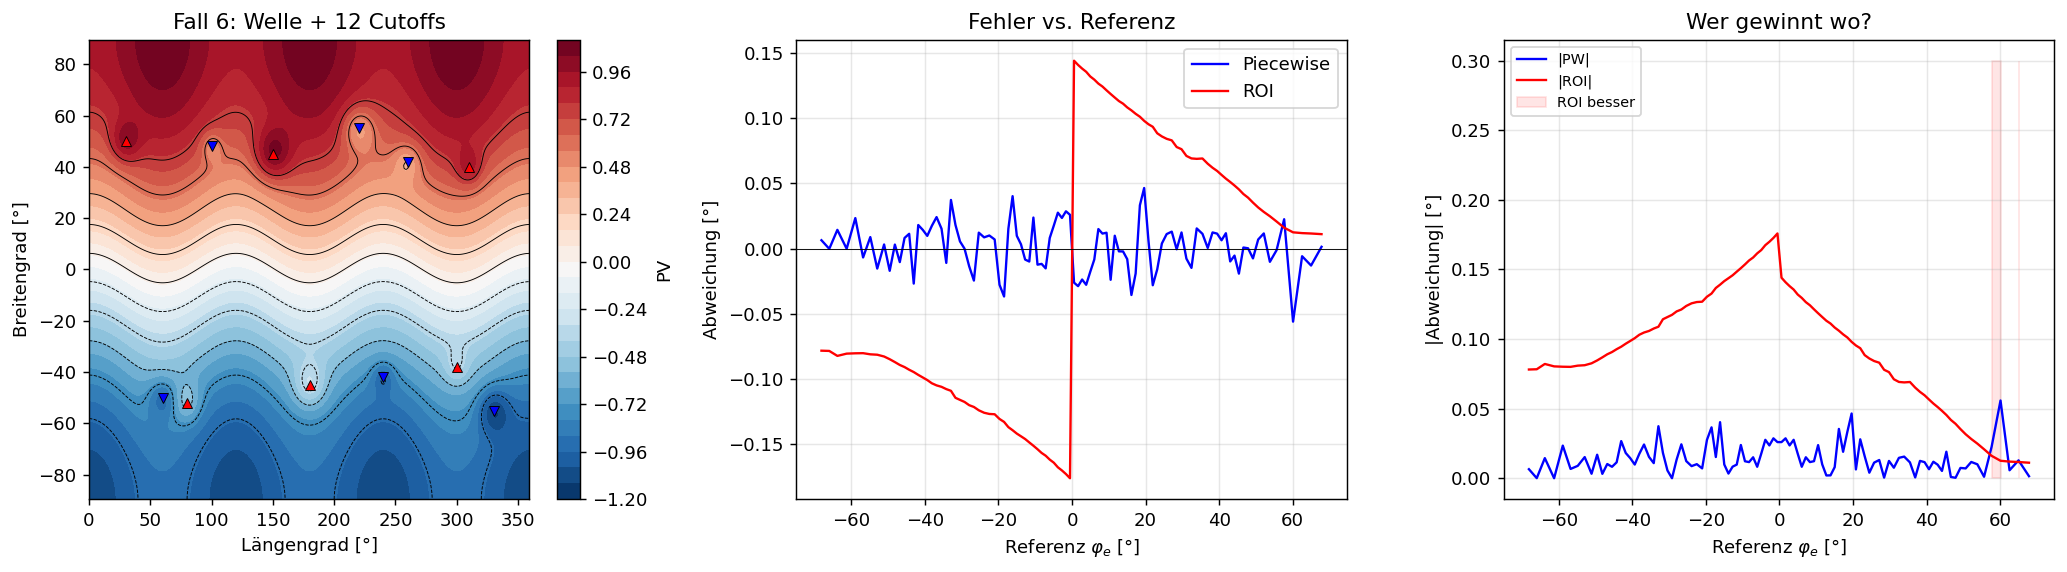

In [103]:
# --- Fall 3: Welle + Cutoffs (12 Cutoffs) ---

a_wave6 = 0.1   # Wellenamplitude (wie Fall 3b)
k_wave6 = 3      # Wellenzahl

# 12 Cutoffs: je 3 positive + 3 negative pro Hemisphäre
cutoffs_6 = [
    # NH positive (Cutoff-Tiefs: hohe PV abgetrennt vom Vortex)
    (45.0, 150.0, 10.0, 15.0, +0.35),   # Stark, Pazifik
    (40.0, 310.0,  7.0, 10.0, +0.20),   # Mittel, Atlantik
    (50.0,  30.0,  8.0, 12.0, +0.25),   # Mittel, Europa
    # NH negative (Blocking-Hochs: niedrige PV polwärts)
    (55.0, 220.0,  9.0, 14.0, -0.30),   # Blocking Pazifik
    (48.0, 100.0,  6.0,  9.0, -0.18),   # Schwach, Zentralasien
    (42.0, 260.0,  7.0, 11.0, -0.22),   # Mittel, Nordamerika
    # SH positive (tropische Luft polwärts = positive Anomalie)
    (-45.0, 180.0, 9.0, 13.0, +0.28),   # Pazifik
    (-38.0, 300.0, 7.0, 10.0, +0.15),   # Südamerika
    (-52.0,  80.0, 8.0, 11.0, +0.22),   # Indischer Ozean
    # SH negative (Cutoff-Tiefs vom SH-Vortex)
    (-50.0,  60.0, 8.0, 12.0, -0.25),   # Stark
    (-42.0, 240.0, 6.0,  9.0, -0.18),   # Mittel
    (-55.0, 330.0, 9.0, 13.0, -0.30),   # Stark, Atlantik
]

def pv_wave_cutoff(lat2d, lon2d):
    """Fall 6: Planetare Welle + 12 isolierte Cutoffs."""
    pv = np.sin(np.deg2rad(lat2d)) - a_wave6 * np.cos(k_wave6 * np.deg2rad(lon2d))
    
    for phi0, lam0, s_phi, s_lam, amp in cutoffs_6:
        dlat_arr = lat2d - phi0
        dlon_arr = lon2d - lam0
        dlon_arr = np.where(dlon_arr > 180, dlon_arr - 360, dlon_arr)
        dlon_arr = np.where(dlon_arr < -180, dlon_arr + 360, dlon_arr)
        pv += amp * np.exp(-(dlat_arr**2 / s_phi**2 + dlon_arr**2 / s_lam**2))
    
    return pv

pv_case6 = pv_wave_cutoff(lat2d, lon2d)

pv_thresh_6 = np.linspace(-0.95, 0.95, n_thresh)

# Hochaufgelöste Referenz
print("Berechne Referenzlösung (0.05°)...")
eqlat_truth_6 = compute_truth(pv_wave_cutoff, pv_thresh_6)

# Beide Methoden
res_pw_6 = equivalent_latitude_piecewise(pv_case6, lat, lon,
                                         pv_thresholds=pv_thresh_6)
res_roi_6 = equivalent_latitude_roi(pv_case6, lat, lon,
                                    pv_thresholds=pv_thresh_6)

diff_pw_6 = res_pw_6['eqlat'] - eqlat_truth_6
diff_roi_6 = res_roi_6['eqlat'] - eqlat_truth_6

pw_better = np.abs(diff_pw_6) < np.abs(diff_roi_6)

print(f"\nFall 6: Welle (a={a_wave6}, k={k_wave6}) + {len(cutoffs_6)} Cutoffs")
print(f"  NH: 3 positive (Cutoff-Tiefs) + 3 negative (Blocking)")
print(f"  SH: 3 positive + 3 negative")
print(f"  PW:  max|Δφ_e| = {np.max(np.abs(diff_pw_6)):.3f}°, "
      f"mean|Δφ_e| = {np.mean(np.abs(diff_pw_6)):.3f}°")
print(f"  ROI: max|Δφ_e| = {np.max(np.abs(diff_roi_6)):.3f}°, "
      f"mean|Δφ_e| = {np.mean(np.abs(diff_roi_6)):.3f}°")
print(f"  PW besser bei {pw_better.sum()}/{len(pw_better)} Schwellenwerten")

# --- Visualisierung ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# PV-Feld
ax = axes[0]
c = ax.contourf(lon, lat, pv_case6, levels=30, cmap='RdBu_r')
ax.contour(lon, lat, pv_case6, levels=pv_thresh_6[::10],
           colors='k', linewidths=0.5)
plt.colorbar(c, ax=ax, label='PV')
ax.set_title(f'Fall 6: Welle + {len(cutoffs_6)} Cutoffs')
ax.set_xlabel('Längengrad [°]')
ax.set_ylabel('Breitengrad [°]')
# Markiere Cutoff-Zentren
for phi0, lam0, _, _, amp in cutoffs_6:
    marker = '^' if amp > 0 else 'v'
    color = 'red' if amp > 0 else 'blue'
    ax.plot(lam0, phi0, marker, ms=6, color=color, markeredgecolor='k', markeredgewidth=0.5)

# Abweichung
ax = axes[1]
ax.plot(eqlat_truth_6, diff_pw_6, 'b-', lw=1.3, label='Piecewise')
ax.plot(eqlat_truth_6, diff_roi_6, 'r-', lw=1.3, label='ROI')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Referenz $\\varphi_e$ [°]')
ax.set_ylabel('Abweichung [°]')
ax.set_title('Fehler vs. Referenz')
ax.legend()
ax.grid(True, alpha=0.3)

# |Fehler| Vergleich
ax = axes[2]
ax.plot(eqlat_truth_6, np.abs(diff_pw_6), 'b-', lw=1.3, label='|PW|')
ax.plot(eqlat_truth_6, np.abs(diff_roi_6), 'r-', lw=1.3, label='|ROI|')
roi_better = ~pw_better
if np.any(roi_better):
    ax.fill_between(eqlat_truth_6, 0, 0.3,
                    where=roi_better, alpha=0.1, color='red',
                    label='ROI besser')
ax.set_xlabel('Referenz $\\varphi_e$ [°]')
ax.set_ylabel('|Abweichung| [°]')
ax.set_title('Wer gewinnt wo?')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

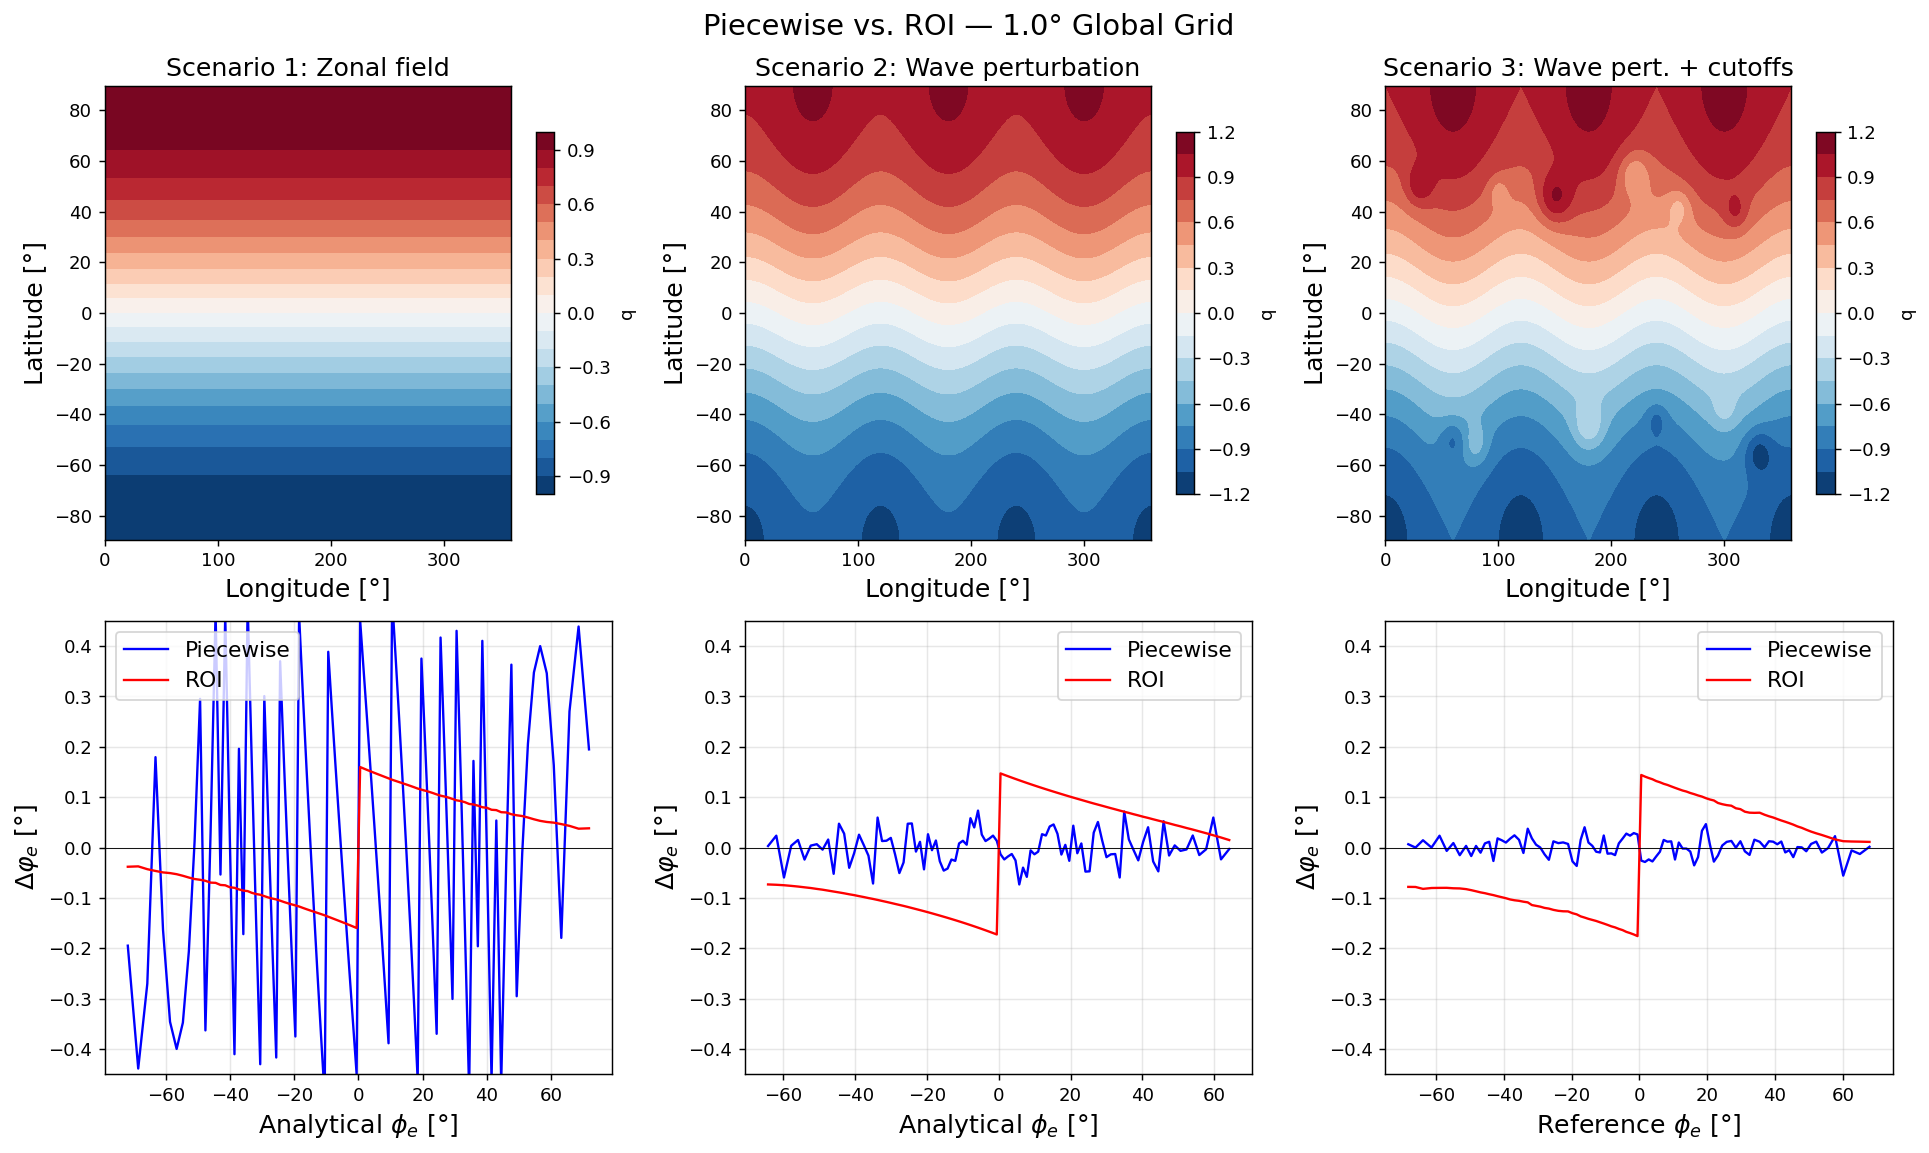

In [104]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# --- Obere Reihe: PV-Felder ---
fields = [
    (pv_case1b, 'Scenario 1: Zonal field'),
    (pv_case2b, f'Scenario 2: Wave perturbation'),
    (pv_case6, 'Scenario 3: Wave pert. + cutoffs'),
]

for ax, (pv_f, title) in zip(axes[0], fields):
    c = ax.contourf(lon, lat, pv_f, levels=20, cmap='RdBu_r')
    plt.colorbar(c, ax=ax, label='q', shrink=0.8)
    ax.set_xlabel('Longitude [°]', fontsize=14)
    ax.set_ylabel('Latitude [°]', fontsize=14)
    ax.set_title(title, fontsize=14)

# --- Untere Reihe: Fehler ---
error_data = [
    (eqlat_an_1b, diff_pw_1b, diff_roi_1b, 'Analytical'),
    (eqlat_an_2b, diff_pw_2b, diff_roi_2b, 'Analytical'),
    (eqlat_truth_6, diff_pw_6, diff_roi_6, 'Reference'),
]

for ax, (eqlat_ref, d_pw, d_roi, ref_label) in zip(axes[1], error_data):
    ax.plot(eqlat_ref, d_pw, 'b-', lw=1.3, label='Piecewise')
    ax.plot(eqlat_ref, d_roi, 'r-', lw=1.3, label='ROI')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(f'{ref_label} $\phi_e$ [°]', fontsize=14)
    ax.set_ylabel('$\\Delta\\varphi_e$ [°]', fontsize=14)
    ax.set_ylim(-0.45, 0.45)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

fig.suptitle(f'Piecewise vs. ROI — {dlat}° Global Grid', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

In [105]:
resolutions = [3.0, 2.5, 2.0, 1.5, 1.0, 0.5, 0.25]

results_conv = {key: [] for key in [
    'dlat',
    'pw_max_1', 'roi_max_1', 'pw_mean_1', 'roi_mean_1',
    'pw_max_2', 'roi_max_2', 'pw_mean_2', 'roi_mean_2',
    'pw_max_3', 'roi_max_3', 'pw_mean_3', 'roi_mean_3',
]}

for dl in resolutions:
    lat_c, lon_c = make_global_grid(dl)
    lon2d_c, lat2d_c = np.meshgrid(lon_c, lat_c)
    results_conv['dlat'].append(dl)


    # Fall 1
    pv_c = np.sin(np.deg2rad(lat2d_c))
    r_pw = equivalent_latitude_piecewise(pv_c, lat_c, lon_c, pv_thresholds=pv_thresh_1b)
    r_roi = equivalent_latitude_roi(pv_c, lat_c, lon_c, pv_thresholds=pv_thresh_1b)
    results_conv['pw_max_1'].append(np.max(np.abs(r_pw['eqlat'] - eqlat_an_1b)))
    results_conv['roi_max_1'].append(np.max(np.abs(r_roi['eqlat'] - eqlat_an_1b)))
    results_conv['pw_mean_1'].append(np.mean(np.abs(r_pw['eqlat'] - eqlat_an_1b)))
    results_conv['roi_mean_1'].append(np.mean(np.abs(r_roi['eqlat'] - eqlat_an_1b)))

    # Fall 2
    pv_c = np.sin(np.deg2rad(lat2d_c)) - a_wave * np.cos(k_wave2 * np.deg2rad(lon2d_c))
    r_pw = equivalent_latitude_piecewise(pv_c, lat_c, lon_c, pv_thresholds=pv_thresh_2b)
    r_roi = equivalent_latitude_roi(pv_c, lat_c, lon_c, pv_thresholds=pv_thresh_2b)
    results_conv['pw_max_2'].append(np.max(np.abs(r_pw['eqlat'] - eqlat_an_2b)))
    results_conv['roi_max_2'].append(np.max(np.abs(r_roi['eqlat'] - eqlat_an_2b)))
    results_conv['pw_mean_2'].append(np.mean(np.abs(r_pw['eqlat'] - eqlat_an_2b)))
    results_conv['roi_mean_2'].append(np.mean(np.abs(r_roi['eqlat'] - eqlat_an_2b)))


    # Fall 4
    pv_c = pv_wave_cutoff(lat2d_c, lon2d_c)
    r_pw = equivalent_latitude_piecewise(pv_c, lat_c, lon_c, pv_thresholds=pv_thresh_6)
    r_roi = equivalent_latitude_roi(pv_c, lat_c, lon_c, pv_thresholds=pv_thresh_6)
    results_conv['pw_max_3'].append(np.max(np.abs(r_pw['eqlat'] - eqlat_truth_6)))
    results_conv['roi_max_3'].append(np.max(np.abs(r_roi['eqlat'] - eqlat_truth_6)))
    results_conv['pw_mean_3'].append(np.mean(np.abs(r_pw['eqlat'] - eqlat_truth_6)))
    results_conv['roi_mean_3'].append(np.mean(np.abs(r_roi['eqlat'] - eqlat_truth_6)))

    print(f"  {dl:5.2f}° done")

   3.00° done
   2.50° done
   2.00° done
   1.50° done
   1.00° done
   0.50° done
   0.25° done


In [106]:
import pandas as pd

df = pd.DataFrame({
    'Δlat [°]': results_conv['dlat'],
    'S1 PW max': results_conv['pw_max_1'],
    'S1 ROI max': results_conv['roi_max_1'],
    'S1 PW mean': results_conv['pw_mean_1'],
    'S1 ROI mean': results_conv['roi_mean_1'],
    'S2 PW max': results_conv['pw_max_2'],
    'S2 ROI max': results_conv['roi_max_2'],
    'S2 PW mean': results_conv['pw_mean_2'],
    'S2 ROI mean': results_conv['roi_mean_2'],
    'S3 PW max': results_conv['pw_max_3'],
    'S3 ROI max': results_conv['roi_max_3'],
    'S3 PW mean': results_conv['pw_mean_3'],
    'S3 ROI mean': results_conv['roi_mean_3'],
})

df.style \
    .format({c: '{:.4f}' for c in df.columns if c != 'Δlat [°]'}) \
    .set_caption('Convergence: max/mean |Δφ_e| [°] per scenario and method') \
    .set_table_styles([{'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold')]}])

,Δlat [°],S1 PW max,S1 ROI max,S1 PW mean,S1 ROI mean,S2 PW max,S2 ROI max,S2 PW mean,S2 ROI mean,S3 PW max,S3 ROI max,S3 PW mean,S3 ROI mean
0,3.000000,1.4949,0.4925,0.7191,0.3193,0.3604,0.5307,0.1217,0.3255,0.3102,0.5403,0.0888,0.3159
1,2.500000,1.1577,0.4077,0.6487,0.2599,0.2596,0.4397,0.0714,0.2668,0.2031,0.4474,0.0755,0.2587
2,2.000000,0.9885,0.3240,0.5197,0.2040,0.1684,0.3495,0.0611,0.2098,0.1935,0.3560,0.0468,0.2032
3,1.500000,0.7494,0.2414,0.3659,0.1503,0.1104,0.2606,0.0430,0.1546,0.1100,0.2654,0.0343,0.1496
4,1.000000,0.4949,0.1598,0.2529,0.0981,0.0733,0.1726,0.0263,0.1013,0.0559,0.1759,0.0145,0.0979
5,0.500000,0.2499,0.0794,0.1217,0.0480,0.0275,0.0858,0.0085,0.0497,0.0214,0.0875,0.0074,0.0480
6,0.250000,0.1248,0.0395,0.0627,0.0238,0.0088,0.0427,0.0028,0.0246,0.0065,0.0437,0.0026,0.0238


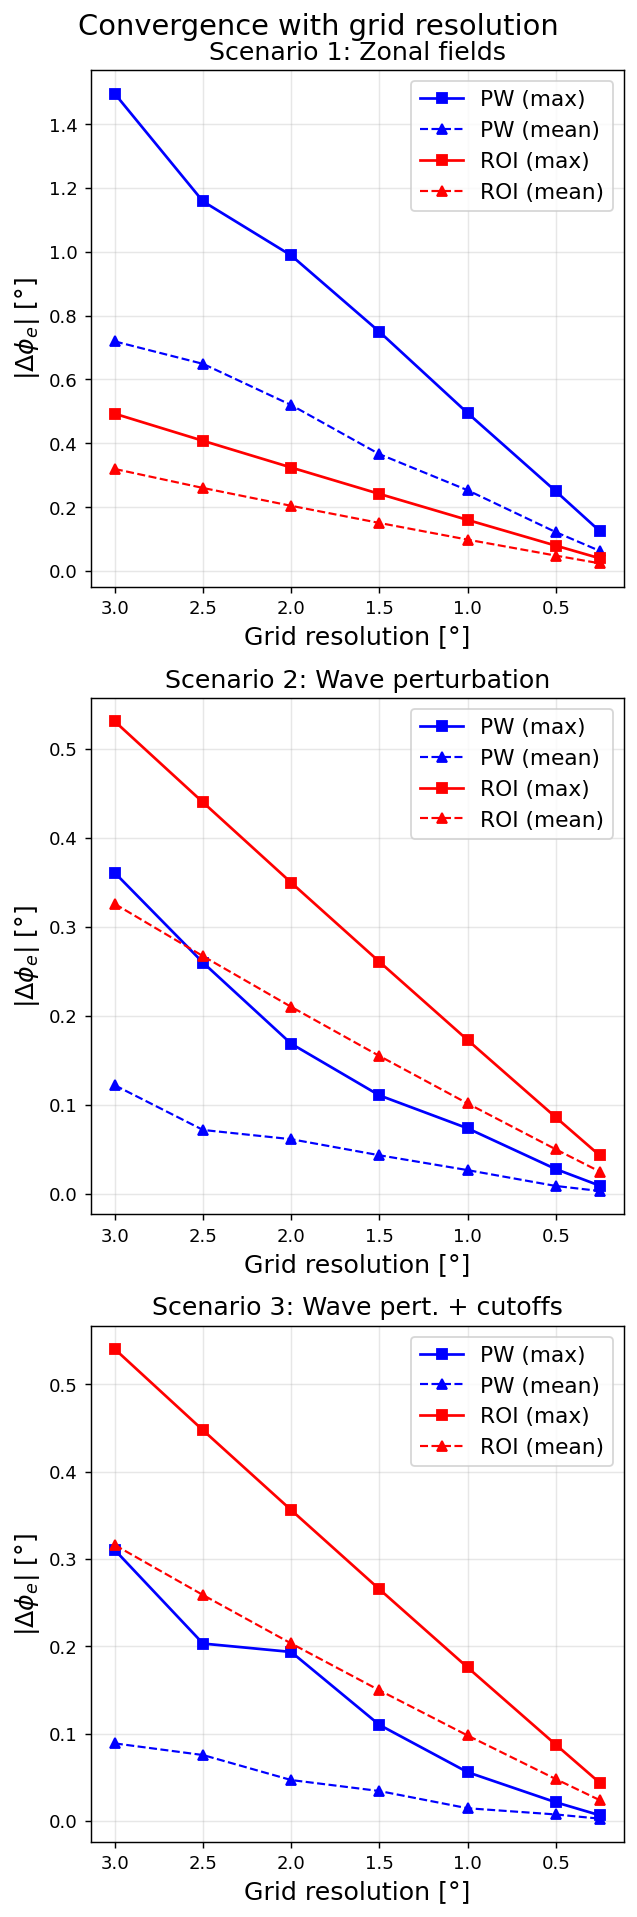

In [108]:
fig, axes = plt.subplots(3, 1, figsize=(5, 15))
dl = np.array(results_conv['dlat'])

for ax, suffix, title in [
    (axes[0], '1', 'Scenario 1: Zonal fields'),
    (axes[1], '2', f'Scenario 2: Wave perturbation'),
    (axes[2], '3', 'Scenario 3: Wave pert. + cutoffs'),
]:
    ax.plot(dl, results_conv[f'pw_max_{suffix}'], 'bs-', lw=1.5,
              markersize=6, label='PW (max)')
    ax.plot(dl, results_conv[f'pw_mean_{suffix}'], 'b^--', lw=1.2,
              markersize=5, label='PW (mean)')
    ax.plot(dl, results_conv[f'roi_max_{suffix}'], 'rs-', lw=1.5,
              markersize=6, label='ROI (max)')
    ax.plot(dl, results_conv[f'roi_mean_{suffix}'], 'r^--', lw=1.2,
              markersize=5, label='ROI (mean)')
    ax.set_xlabel('Grid resolution [°]', fontsize=14)
    ax.set_ylabel('|Δ$\phi_e$| [°]', fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(True, which='both', alpha=0.3)
    ax.invert_xaxis()

fig.suptitle('Convergence with grid resolution', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()